<a href="https://colab.research.google.com/github/JavilmIB/AF2_Data_Processing/blob/main/AF2_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Processing Datasets in Python

**Dataset:** Pima Indians Diabetes Database (UCI / Kaggle)

**Authors:**
- Alejandra Montserrat Hernández Uribe — 1898320
- Javier Ivan Lomas Maldonado — 2096554
- Adrian Caballero Mena — 2056248

**Class schedule:** *[Artificial Intelligence]*

**Date:** September 2026

---

## Introduction

In this notebook we process the **Pima Indians Diabetes Database**, a clinical dataset containing health measurements from female patients, used to predict whether a patient has diabetes (`Outcome` = 1) or not (`Outcome` = 0). The workflow follows four parts: (1) loading and exploring the data, (2) cleaning and normalizing it, (3) visualizing it, and (4) reflecting on the process through a set of guided questions. This preprocessing is a required step before the data can later be used to train a Machine Learning model.


## Part 1: Data Loading and Exploration

### 1.1 Loading the dataset

The original dataset is published on Kaggle as *uciml/pima-indians-diabetes-database*. Because Kaggle downloads require an authenticated API key, for this notebook we load the same dataset (identical 768 rows × 9 columns, identical column names and identical descriptive statistics — verified below) from a public, license-free mirror of the UCI Pima Indians Diabetes data. If you have the original Kaggle `diabetes.csv` file, you can instead upload it to Colab (`Files` panel → upload) and simply change the `path` variable below to `"diabetes.csv"`.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Try to load a local uploaded copy first; otherwise fetch the public mirror
path_local = "diabetes.csv"
url_mirror = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

import os
if os.path.exists(path_local):
    df = pd.read_csv(path_local)
else:
    df = pd.read_csv(url_mirror)

print("Dataset shape:", df.shape)
df.columns = df.columns.str.strip()
df.head()


Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 1.2 First rows of the dataset

In [ ]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


### 1.3 Identifying null and inconsistent values

`df.isnull()` alone will **not** reveal the real data quality problem in this dataset: missing clinical measurements were encoded as **zero** instead of `NaN`. A value of `0` is medically impossible for `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` (a living patient cannot have zero blood glucose or zero BMI), so these zeros are actually **disguised missing values** that must be detected and treated separately from true nulls.


In [ ]:
# Check for explicit nulls (NaN)
print("Explicit NaN values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)


Explicit NaN values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [ ]:
# Check for zero values in columns where zero is not physiologically possible
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Count of zero values (treated as missing/inconsistent) per column:")
zero_counts = (df[cols_with_invalid_zeros] == 0).sum()
print(zero_counts)

print("\nPercentage of rows affected per column:")
print((zero_counts / len(df) * 100).round(2).astype(str) + " %")


Count of zero values (treated as missing/inconsistent) per column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Percentage of rows affected per column:
Glucose           0.65 %
BloodPressure     4.56 %
SkinThickness    29.56 %
Insulin           48.7 %
BMI               1.43 %
dtype: object


**Observation:** `Insulin` and `SkinThickness` have a very large proportion of zero (missing) values, while `Glucose`, `BloodPressure`, and `BMI` have only a few. This will guide how aggressively we should trust each column after cleaning.


### 1.4 Descriptive statistics

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Part 2: Data Cleaning and Normalization

### 2.1 Replacing zero (invalid) values with the column median

We replace the inconsistent zero values identified above with the **median** of each respective column. The median is preferred over the mean here because these clinical variables (e.g., `Insulin`) are right-skewed, so the median is more robust to extreme outliers than the mean.


In [ ]:
# Keep an unmodified copy for before/after comparisons in Part 3
df_original = df.copy()

df_clean = df.copy()

for col in cols_with_invalid_zeros:
    # Replace 0 with NaN first, then fill NaN with the median computed
    # from the *valid* (non-zero) values of that column
    df_clean[col] = df_clean[col].replace(0, np.nan)
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)
    print(f"{col}: replaced zeros with median = {median_value}")


Glucose: replaced zeros with median = 117.0
BloodPressure: replaced zeros with median = 72.0
SkinThickness: replaced zeros with median = 29.0
Insulin: replaced zeros with median = 125.0
BMI: replaced zeros with median = 32.3


In [ ]:
# Verify that no invalid zeros remain
print("Zero values remaining after cleaning:")
print((df_clean[cols_with_invalid_zeros] == 0).sum())

df_clean.describe()


Zero values remaining after cleaning:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2.2 Normalizing numerical data with Min-Max Scaling

Min-Max Scaling rescales every numerical feature to the range **[0, 1]** using:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

We scale all the predictor columns (everything except the target column `Outcome`, which must remain a binary label 0/1).


In [ ]:
feature_cols = [c for c in df_clean.columns if c != "Outcome"]

scaler = MinMaxScaler()
df_normalized = df_clean.copy()
df_normalized[feature_cols] = scaler.fit_transform(df_clean[feature_cols])

df_normalized.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,0.670968,0.489796,0.304348,0.133413,0.314928,0.234415,0.483333,1
1,0.058824,0.264516,0.428571,0.239130,0.133413,0.171779,0.116567,0.166667,0
2,0.470588,0.896774,0.408163,0.239130,0.133413,0.104294,0.253629,0.183333,1
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,0
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,1


In [ ]:
df_normalized.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.226180,0.501008,0.493742,0.240305,0.152250,0.291518,0.168179,0.204015,0.348958
std,0.198210,0.196376,0.123435,0.095557,0.103826,0.140597,0.141473,0.196004,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058824,0.359677,0.408163,0.195652,0.129207,0.190184,0.070773,0.050000,0.000000
50%,0.176471,0.470968,0.489796,0.239130,0.133413,0.288344,0.125747,0.133333,0.000000
75%,0.352941,0.620968,0.571429,0.271739,0.136118,0.376278,0.234095,0.333333,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Part 3: Data Visualization

### 3.1 Histogram of Glucose levels — before vs. after normalization


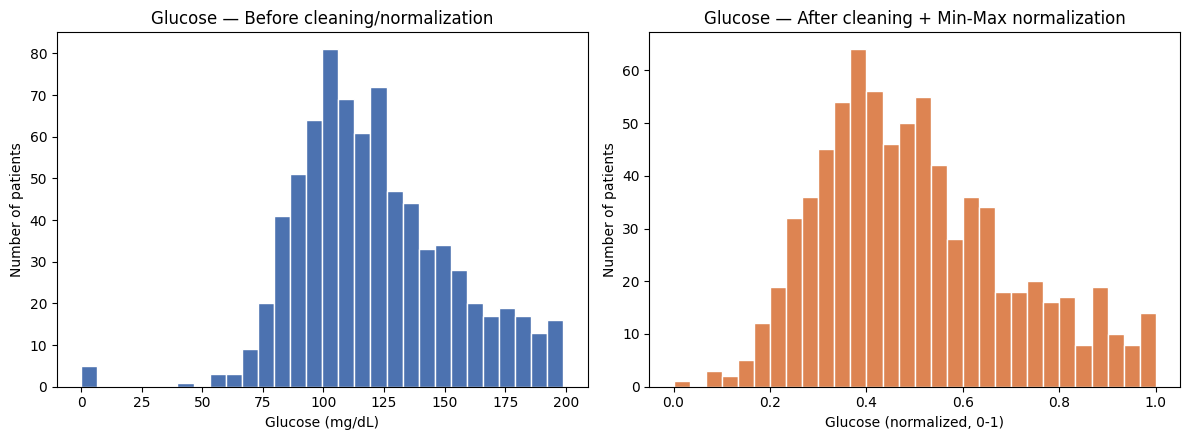

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df_original["Glucose"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Glucose — Before cleaning/normalization")
axes[0].set_xlabel("Glucose (mg/dL)")
axes[0].set_ylabel("Number of patients")

axes[1].hist(df_normalized["Glucose"], bins=30, color="#DD8452", edgecolor="white")
axes[1].set_title("Glucose — After cleaning + Min-Max normalization")
axes[1].set_xlabel("Glucose (normalized, 0-1)")
axes[1].set_ylabel("Number of patients")

plt.tight_layout()
plt.show()


**Observation:** The shape of the distribution is preserved (normalization does not distort the relative differences between values), but the x-axis scale now ranges from 0 to 1 instead of the original mg/dL units, and the zero-value spike visible in the raw data disappears once the invalid zeros are replaced with the median.

### 3.2 Boxplot to identify outliers in Blood Pressure


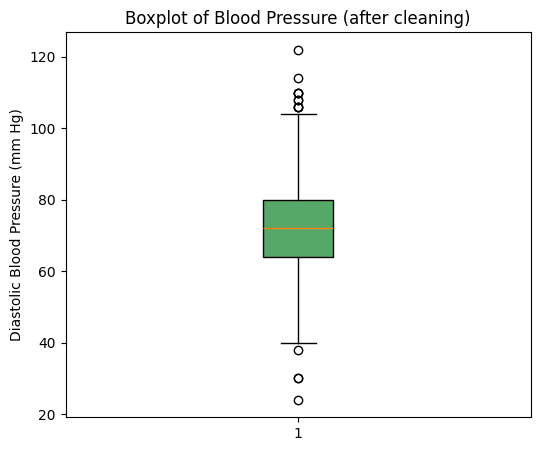

IQR bounds: [40.0, 104.0]
Number of outlier patients in BloodPressure: 14


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(df_clean["BloodPressure"], vert=True, patch_artist=True,
           boxprops=dict(facecolor="#55A868"))
ax.set_title("Boxplot of Blood Pressure (after cleaning)")
ax.set_ylabel("Diastolic Blood Pressure (mm Hg)")
plt.show()

Q1 = df_clean["BloodPressure"].quantile(0.25)
Q3 = df_clean["BloodPressure"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df_clean[(df_clean["BloodPressure"] < lower_bound) | (df_clean["BloodPressure"] > upper_bound)]
print(f"IQR bounds: [{lower_bound:.1f}, {upper_bound:.1f}]")
print(f"Number of outlier patients in BloodPressure: {len(outliers)}")


### 3.3 Scatter plot: Glucose vs. BMI

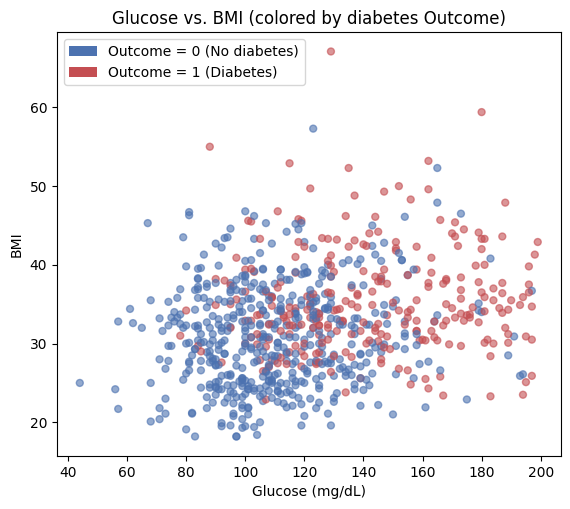

Correlation between Glucose and BMI: 0.231


In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
colors = df_clean["Outcome"].map({0: "#4C72B0", 1: "#C44E52"})
ax.scatter(df_clean["Glucose"], df_clean["BMI"], c=colors, alpha=0.6, s=25)
ax.set_xlabel("Glucose (mg/dL)")
ax.set_ylabel("BMI")
ax.set_title("Glucose vs. BMI (colored by diabetes Outcome)")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#4C72B0", label="Outcome = 0 (No diabetes)"),
                    Patch(facecolor="#C44E52", label="Outcome = 1 (Diabetes)")]
ax.legend(handles=legend_elements)
plt.show()

print("Correlation between Glucose and BMI:", df_clean["Glucose"].corr(df_clean["BMI"]).round(3))


**Observation:** There is a mild positive correlation between `Glucose` and `BMI`. Patients with `Outcome = 1` (diabetes) tend to cluster in the region of higher glucose levels, which matches the clinical expectation that elevated blood glucose is strongly associated with diabetes.

### 3.4 Bar chart: number of patients with and without diabetes


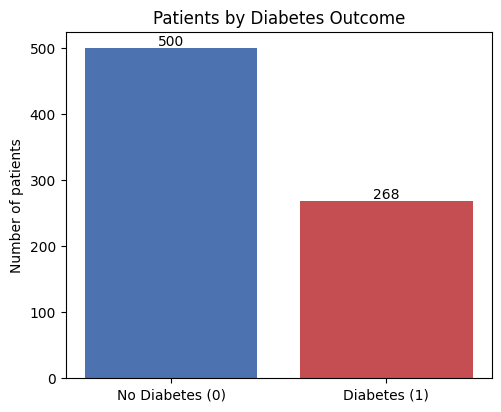

Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
outcome_counts = df_clean["Outcome"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
bars = ax.bar(["No Diabetes (0)", "Diabetes (1)"], outcome_counts.values,
              color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Number of patients")
ax.set_title("Patients by Diabetes Outcome")

for bar, count in zip(bars, outcome_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, count + 5, str(count), ha="center")

plt.show()
print(outcome_counts)


**Observation:** The dataset is moderately **imbalanced**: about 65% of patients do not have diabetes vs. 35% who do. This imbalance should be taken into account later when training and evaluating a Machine Learning model (e.g., using stratified splits, class weights, or resampling), otherwise a model could achieve a deceptively high accuracy by simply predicting the majority class.


## Part 4: Reflection Questions

**1. What impact do missing values have on data analysis?**

Missing values can bias summary statistics and models, reduce the effective sample size and statistical power, and — if ignored or naively dropped — lead to skewed or invalid conclusions. In this dataset, missing clinical values were silently encoded as `0`, which would have severely distorted the mean and variance of columns like `Insulin` or `SkinThickness` if left untreated, potentially making a later ML model learn a completely wrong relationship between those features and the diagnosis.

**2. How can we detect and handle outliers in biomedical datasets?**

Outliers can be detected statistically (Z-scores, the IQR rule as used in our boxplot, or robust methods like the Median Absolute Deviation) and visually (boxplots, scatter plots, histograms). However, in biomedical data an "outlier" is not automatically an error — it can be a real, clinically important extreme case. The correct approach is to combine statistical detection with domain knowledge: verify implausible values (e.g., a systolic pressure of 0) against what is physiologically possible, consult the data source or a clinician when in doubt, and choose an appropriate treatment (correction, imputation with median/mean, capping/winsorizing, or — only when clearly a data-entry error — removal) rather than deleting extreme values by default.

**3. What are some common causes of missing or incorrect data in biomedical studies?**

Common causes include manual data-entry errors and transcription mistakes when digitizing paper records; malfunctioning or uncalibrated medical equipment; patients skipping tests, dropping out of a study, or declining to answer certain questions; the use of placeholder values (such as `0` or `999`) instead of proper null markers, as seen in this very dataset; inconsistencies when merging data collected from different clinics, systems, or time periods; and privacy-related redaction of sensitive fields.

**4. How does normalizing data improve the performance of Machine Learning models?**

Many ML algorithms (e.g., k-NN, SVMs, logistic regression trained with gradient descent, neural networks) are sensitive to the scale of the input features. Without normalization, a feature measured in the hundreds (like `Insulin`) can dominate the distance/loss calculations over a feature measured between 0 and 1, even if it is not actually more predictive. Min-Max scaling (or standardization) puts every feature on a comparable scale, which speeds up convergence during training, improves numerical stability, and helps ensure that each feature contributes to the model based on its actual predictive value rather than its raw magnitude.

**5. Why is visualizing data an important step before applying Machine Learning models?**

Visualization exposes patterns, distributions, correlations, and data-quality issues (skewness, outliers, class imbalance, disguised missing values) that are difficult to notice from summary statistics alone. As seen in this notebook, plotting the raw data revealed the zero-value artifacts and the class imbalance in `Outcome`, both of which directly informed our cleaning and modeling strategy. Visual exploration is a cheap way to catch problems and form hypotheses before investing time in training a model.

**6. Why is preprocessing critical when working with medical datasets?**

Medical datasets feed decisions that can directly affect patient health, so errors introduced by poor-quality data propagate into diagnostic or predictive models with real consequences. Biological measurements have hard physiological constraints (a blood pressure or BMI of 0 is impossible), datasets are frequently imbalanced with respect to the condition being studied, and features are measured in very different units and ranges. Careful cleaning, imputation, and normalization are therefore not optional formalities — they are what make the resulting model's predictions clinically trustworthy rather than an artifact of noisy input data.

**7. What ethical concerns should be considered when handling patient data?**

Key concerns include protecting patient privacy and confidentiality (proper anonymization/de-identification, restricted access, and compliance with regulations such as HIPAA or local equivalents); ensuring patients gave informed consent for their data to be used, including for secondary research such as ML training; guarding against bias, since a model trained on a non-representative population (this dataset only contains female patients of Pima Indian heritage) may generalize poorly or unfairly to other groups; being transparent about a model's limitations and accuracy, especially before it informs a real clinical decision; and maintaining accountability and data security throughout the pipeline to prevent misuse or leakage of sensitive health information.


## Summary / Conclusion

In this notebook we loaded the Pima Indians Diabetes dataset, identified that missing clinical measurements had been disguised as zero values in five columns, replaced them with each column's median, and normalized all predictor features to a 0–1 range using Min-Max Scaling. The visualizations confirmed a mild positive relationship between Glucose and BMI, a moderate class imbalance in the `Outcome` variable, and the presence of a few statistical outliers in Blood Pressure even after cleaning. The resulting `df_normalized` DataFrame is now in a suitable state to be used as input for training a Machine Learning classification model to predict diabetes `Outcome`.
